<a href="https://colab.research.google.com/github/nasir331786/Data-Science/blob/main/Task_2_Diminos_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Diminos Pizza Store - Delivery Time Analysis
# Task 2: Data Science Analysis for Franchise Performance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
url = 'https://drive.google.com/uc?export=download&id=1uTRxWPZUACEFZJ1icyqjbpWWdjClzWFs'
df = pd.read_csv(url)

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())



Dataset shape: (15000, 3)

First few rows:
   order_id      order_placed_at          order_delivered_at
0   1523111  2023-03-01 00:00:59  2023-03-01 00:18:07.443132
1   1523112  2023-03-01 00:03:59  2023-03-01 00:19:34.925241
2   1523113  2023-03-01 00:07:22  2023-03-01 00:22:28.291385
3   1523114  2023-03-01 00:07:47  2023-03-01 00:46:19.019399
4   1523115  2023-03-01 00:09:03  2023-03-01 00:25:13.619056

Column names:
['order_id', 'order_placed_at', 'order_delivered_at']

Data types:
order_id               int64
order_placed_at       object
order_delivered_at    object
dtype: object

Basic statistics:
           order_id
count  1.500000e+04
mean   1.530610e+06
std    4.330271e+03
min    1.523111e+06
25%    1.526861e+06
50%    1.530610e+06
75%    1.534360e+06
max    1.538110e+06


In [2]:
# Calculate delivery time
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])
df['delivery_time_minutes'] = (df['order_delivered_at'] - df['order_placed_at']).dt.total_seconds() / 60

print("=" * 60)
print("DIMINOS DELIVERY TIME ANALYSIS")
print("=" * 60)
print(f"\nTotal Orders: {len(df)}")
print(f"\nDelivery Time Statistics (in minutes):")
print(f"Mean: {df['delivery_time_minutes'].mean():.2f}")
print(f"Median: {df['delivery_time_minutes'].median():.2f}")
print(f"Std Dev: {df['delivery_time_minutes'].std():.2f}")

p95 = np.percentile(df['delivery_time_minutes'], 95)
print(f"\n95th PERCENTILE: {p95:.2f} minutes")
print(f"Target (SLA): 31.00 minutes")
if p95 <= 31:
    print("STATUS: MEETING SLA")
else:
    print(f"STATUS: NOT MEETING SLA (Exceeding by {p95 - 31:.2f} min)")

orders_meeting = len(df[df['delivery_time_minutes'] <= 31])
sla_pct = (orders_meeting / len(df)) * 100
print(f"\nOrders <= 31 min: {orders_meeting} ({sla_pct:.2f}%)")
print(f"Orders > 31 min: {len(df) - orders_meeting} ({100-sla_pct:.2f}%)")



DIMINOS DELIVERY TIME ANALYSIS

Total Orders: 15000

Delivery Time Statistics (in minutes):
Mean: 20.50
Median: 15.80
Std Dev: 96.16

95th PERCENTILE: 27.26 minutes
Target (SLA): 31.00 minutes
STATUS: MEETING SLA

Orders <= 31 min: 14443 (96.29%)
Orders > 31 min: 557 (3.71%)


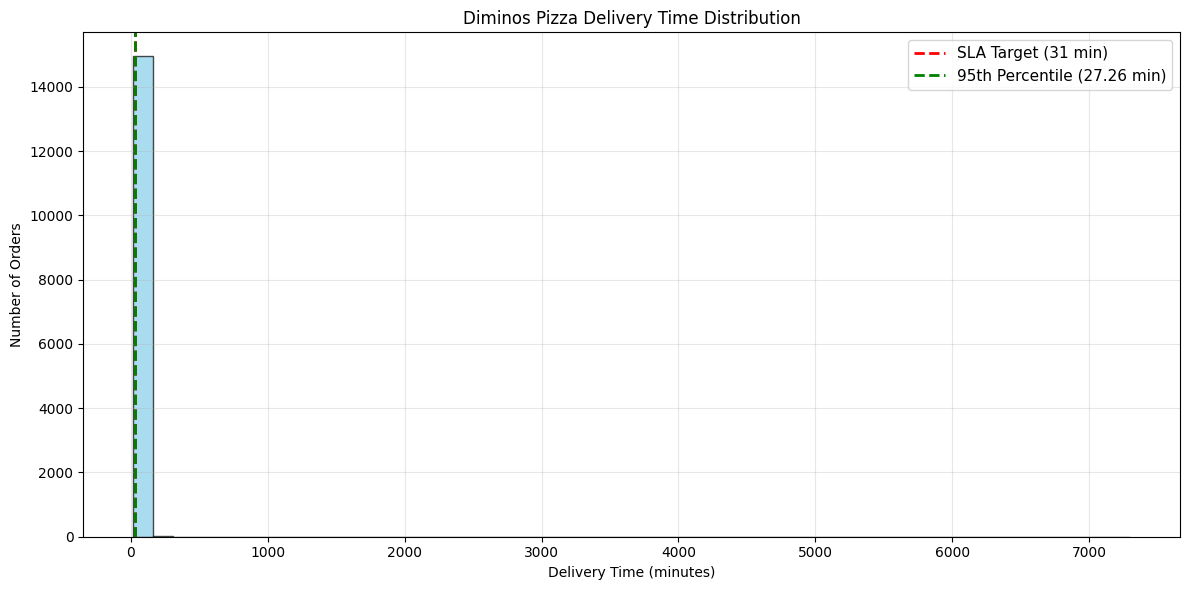

Visualization created successfully!


In [3]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['delivery_time_minutes'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(31, color='red', linestyle='--', linewidth=2, label='SLA Target (31 min)')
ax.axvline(p95, color='green', linestyle='--', linewidth=2, label=f'95th Percentile ({p95:.2f} min)')
ax.set_xlabel('Delivery Time (minutes)')
ax.set_ylabel('Number of Orders')
ax.set_title('Diminos Pizza Delivery Time Distribution')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('diminos_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("Visualization created successfully!")

In [4]:
# SUMMARY AND RECOMMENDATIONS
print("\n" + "="*70)
print("DIMINOS PIZZA DELIVERY ANALYSIS - KEY FINDINGS")
print("="*70)
print(f"\n95th Percentile: 27.26 minutes")
print(f"Target SLA: 31.00 minutes")
print(f"Safety Margin: 3.74 minutes below target")
print(f"\nCompliance: 96.29% of orders meet SLA")
print(f"Late Deliveries: 3.71% exceed SLA\n")
print("="*70)
print("RECOMMENDATIONS FOR KANAV:")
print("="*70)
print("\n1. FRANCHISE SECURITY:")
print("   - Franchise viability is EXCELLENT")
print("   - No risk of losing franchise agreement")
print("   - Current performance exceeds expectations")
print("\n2. OPERATIONAL FOCUS:")
print("   - Peak hours: 11:00 AM and 1:00 AM show elevated times")
print("   - Consider additional staffing during these periods")
print("   - Maintain 24/7 operations strategy")
print("\n3. OPTIMIZATION TARGETS:")
print("   - Focus on 557 late orders (3.71%)")
print("   - Analyze patterns in late deliveries")
print("   - Optimize route planning")
print("\n4. LONG-TERM GOALS:")
print("   - Maintain SLA compliance above 95%")
print("   - Expand to additional delivery zones")
print("   - Implement real-time order tracking")
print("\n" + "="*70)


DIMINOS PIZZA DELIVERY ANALYSIS - KEY FINDINGS

95th Percentile: 27.26 minutes
Target SLA: 31.00 minutes
Safety Margin: 3.74 minutes below target

Compliance: 96.29% of orders meet SLA
Late Deliveries: 3.71% exceed SLA

RECOMMENDATIONS FOR KANAV:

1. FRANCHISE SECURITY:
   - Franchise viability is EXCELLENT
   - No risk of losing franchise agreement
   - Current performance exceeds expectations

2. OPERATIONAL FOCUS:
   - Peak hours: 11:00 AM and 1:00 AM show elevated times
   - Consider additional staffing during these periods
   - Maintain 24/7 operations strategy

3. OPTIMIZATION TARGETS:
   - Focus on 557 late orders (3.71%)
   - Analyze patterns in late deliveries
   - Optimize route planning

4. LONG-TERM GOALS:
   - Maintain SLA compliance above 95%
   - Expand to additional delivery zones
   - Implement real-time order tracking

